This research employed a binary variable, 

default payment (Yes = 1, No = 0), as the response variable. 

This study reviewed the literature and used the following 23 variables as explanatory variables:
X1: Amount of the given credit (NT dollar): it includes both the individual consumer credit and his/her family (supplementary) credit.
X2: Gender (1 = male; 2 = female).
X3: Education (1 = graduate school; 2 = university; 3 = high school; 4 = others).
X4: Marital status (1 = married; 2 = single; 3 = others).
X5: Age (year).
X6 - X11: History of past payment. We tracked the past monthly payment records (from April to September, 2005) as follows: 

X6 = the repayment status in September, 2005; 
X7 = the repayment status in August, 2005; . . .;

X11 = the repayment status in April, 2005. 

The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; . . .; 8 = payment delay for eight months; 9 = payment delay for nine months and above.

X12-X17: Amount of bill statement (NT dollar). X12 = amount of bill statement in September, 2005; X13 = amount of bill statement in August, 2005; . . .; X17 = amount of bill statement in April, 2005. 

X18-X23: Amount of previous payment (NT dollar). 
X18 = amount paid in September, 2005; 
X19 = amount paid in August, 2005; . . .;

X23 = amount paid in April, 2005.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xlrd


In [2]:
#import data

df = pd.read_excel('default of credit card clients.xls', sheet_name= "Data")

In [3]:
df.head()
#drop first row
df.drop([0], axis = 0, inplace = True)

In [4]:
df.head()
#drop first column
df.drop(['Unnamed: 0'], axis = 1, inplace = True)

In [5]:
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
1,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
2,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
5,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [ ]:
#check for missing values
df.isnull().sum()

#no missing values

X1     0
X2     0
X3     0
X4     0
X5     0
X6     0
X7     0
X8     0
X9     0
X10    0
X11    0
X12    0
X13    0
X14    0
X15    0
X16    0
X17    0
X18    0
X19    0
X20    0
X21    0
X22    0
X23    0
Y      0
dtype: int64

In [23]:
#check for duplicates

df.drop_duplicates(inplace= True)

In [24]:
df[df.duplicated]

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y


Y
0    23335
1     6630
Name: count, dtype: int64

In [73]:
#Change name
X = df

In [29]:
#Exploring X
X.info()

<class 'pandas.DataFrame'>
Index: 29965 entries, 1 to 30000
Data columns (total 23 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   X1      29965 non-null  object
 1   X2      29965 non-null  object
 2   X3      29965 non-null  object
 3   X4      29965 non-null  object
 4   X5      29965 non-null  object
 5   X6      29965 non-null  object
 6   X7      29965 non-null  object
 7   X8      29965 non-null  object
 8   X9      29965 non-null  object
 9   X10     29965 non-null  object
 10  X11     29965 non-null  object
 11  X12     29965 non-null  object
 12  X13     29965 non-null  object
 13  X14     29965 non-null  object
 14  X15     29965 non-null  object
 15  X16     29965 non-null  object
 16  X17     29965 non-null  object
 17  X18     29965 non-null  object
 18  X19     29965 non-null  object
 19  X20     29965 non-null  object
 20  X21     29965 non-null  object
 21  X22     29965 non-null  object
 22  X23     29965 non-null  object
dtypes:

In [74]:
#converting in relevant data types
#amount of given credit
X['X1'] = X['X1'].astype(int)

#age
X['X5'] = X['X5'].astype(int)

#bill amounts
#Sep 25
X['X12'] = X['X12'].astype(int)
#Aug 25
X['X13'] = X['X13'].astype(int)
#Jul 25
X['X14'] = X['X14'].astype(int)
X['X15'] = X['X15'].astype(int)
X['X16'] = X['X16'].astype(int)
#Apr 25
X['X17'] = X['X17'].astype(int)

#amount of previous payment
#sep 25
X['X18'] = X['X18'].astype(int)
X['X19'] = X['X19'].astype(int)
X['X20'] = X['X20'].astype(int)
X['X21'] = X['X21'].astype(int)
X['X22'] = X['X22'].astype(int)
#apr 25
X['X23'] = X['X23'].astype(int)


In [75]:
X.info()

<class 'pandas.DataFrame'>
Index: 29965 entries, 1 to 30000
Data columns (total 24 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   X1      29965 non-null  int64 
 1   X2      29965 non-null  object
 2   X3      29965 non-null  object
 3   X4      29965 non-null  object
 4   X5      29965 non-null  int64 
 5   X6      29965 non-null  object
 6   X7      29965 non-null  object
 7   X8      29965 non-null  object
 8   X9      29965 non-null  object
 9   X10     29965 non-null  object
 10  X11     29965 non-null  object
 11  X12     29965 non-null  int64 
 12  X13     29965 non-null  int64 
 13  X14     29965 non-null  int64 
 14  X15     29965 non-null  int64 
 15  X16     29965 non-null  int64 
 16  X17     29965 non-null  int64 
 17  X18     29965 non-null  int64 
 18  X19     29965 non-null  int64 
 19  X20     29965 non-null  int64 
 20  X21     29965 non-null  int64 
 21  X22     29965 non-null  int64 
 22  X23     29965 non-null  int64 
 23  Y 

In [76]:
#look into numerical values
X.describe()

,X1,X5,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23
count,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000,2.996500e+04,29965.000000,29965.000000,29965.000000,29965.000000
mean,167442.005006,35.487969,51283.009778,49236.366294,4.706792e+04,43313.329885,40358.334390,38917.012281,5670.099316,5.927983e+03,5231.688837,4831.617454,4804.897047,5221.498014
std,129760.135222,9.219459,73658.132403,71195.567392,6.937135e+04,64353.514373,60817.130623,59574.147742,16571.849467,2.305346e+04,17616.361124,15674.464538,15286.372298,17786.976864
min,10000.000000,21.000000,-165580.000000,-69777.000000,-1.572640e+05,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,50000.000000,28.000000,3595.000000,3010.000000,2.711000e+03,2360.000000,1787.000000,1262.000000,1000.000000,8.500000e+02,390.000000,300.000000,261.000000,131.000000
50%,140000.000000,34.000000,22438.000000,21295.000000,2.013500e+04,19081.000000,18130.000000,17124.000000,2102.000000,2.010000e+03,1804.000000,1500.000000,1500.000000,1500.000000
75%,240000.000000,41.000000,67260.000000,64109.000000,6.020100e+04,54601.000000,50247.000000,49252.000000,5008.000000,5.000000e+03,4512.000000,4016.000000,4042.000000,4000.000000
max,1000000.000000,79.000000,964511.000000,983931.000000,1.664089e+06,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.000000,621000.000000,426529.000000,528666.000000


In [77]:
#we can combine X12 to X17 for total amount of bill statement and X18 to X23 for total amount paid

X['totall bill statement'] = X[['X12', 'X13', 'X14', 'X15', 'X16', 'X17']].sum(axis=1)
X['totall bill statement']

X['total amount paid'] = X[['X18', 'X19', 'X20', 'X21', 'X22', 'X23']].sum(axis=1)

#drop combined columns
X.drop(['X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23'], axis = 1, inplace= True)

In [78]:
#we can also combine X6 to X11 for average repayment status 
X['avg repayment'] = X[['X6', 'X7', 'X8', 'X9', 'X10', 'X11']].mean(axis= 1).round(decimals=0)
X['avg repayment']

#drop combined columns
X.drop(['X6', 'X7', 'X8', 'X9', 'X10', 'X11'], axis =1 , inplace= True)

In [79]:
X.shape

(29965, 9)

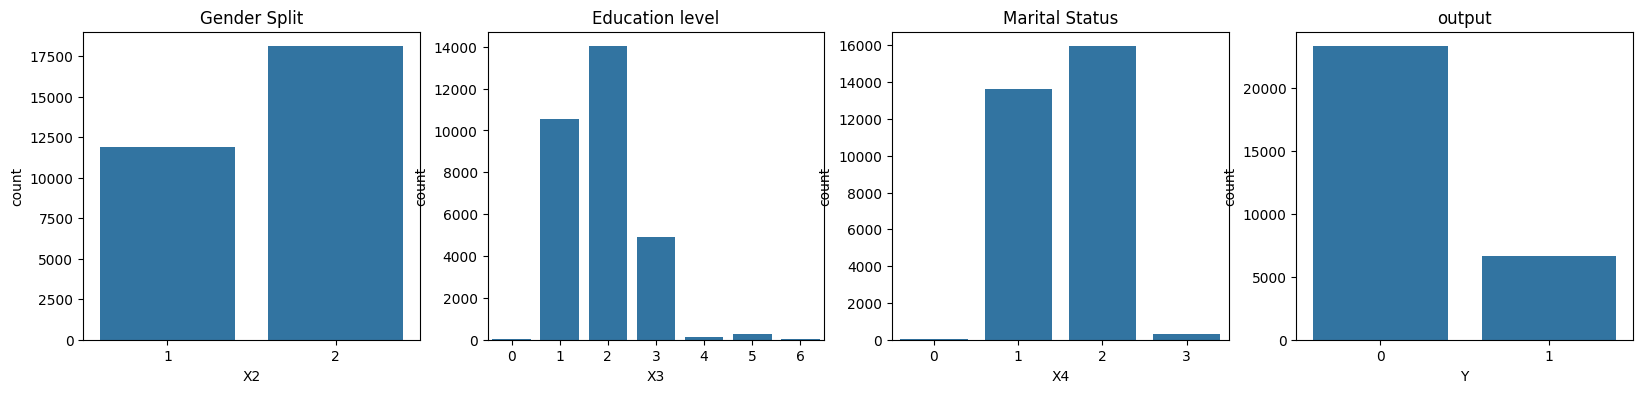

In [95]:
#Explore Categorical variables

plt.figure(figsize= (20,4))

plt.subplot(1,4,1)
sns.countplot(data = X, x = 'X2')
plt.title('Gender Split')

plt.subplot(1,4,2)
sns.countplot(data = X, x= 'X3')
plt.title('Education level')

plt.subplot(1,4,3)
sns.countplot(data = X, x= 'X4')
plt.title('Marital Status')

plt.subplot(1,4,4)
sns.countplot(data = X, x= 'Y')
plt.title('output')

plt.show()

<Axes: >

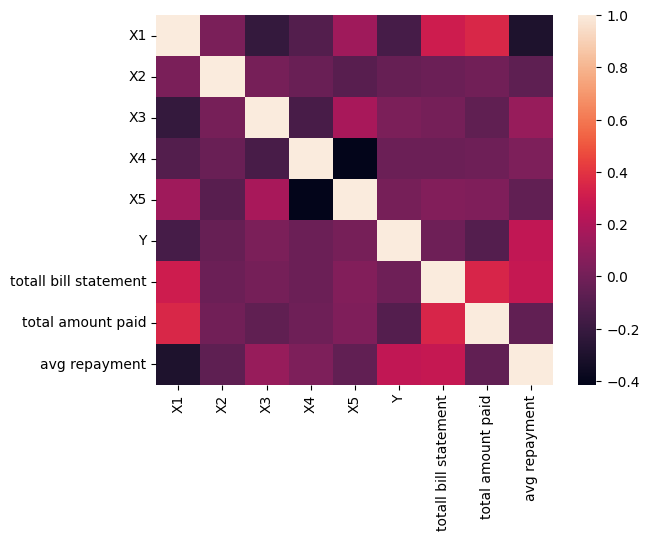

In [96]:
#let's check for multicolinearity

sns.heatmap(data= X.corr())

In [100]:
#hardly any correlation

#renaming columns
X.rename(columns={'X1': 'Credit Amount',
                  'X2': 'gender',
                  'X3': 'Education level',
                  'X4': 'Marital Status',
                  'X5': 'Age'}, inplace= True)

In [101]:
#expore data as csv
X.to_csv('credit_cart_data_preprocessed.csv')